# Evaluating performance of variant growth rate inference of FGA and GARW models

## Notebook Overview

### Objectives
* Define a way to compare model Rt inference with simulated observations 
* Zoom-in on on a well-performing window and ones that contradict biological intuition despite decent performance metrics, as well as those that just perform poorly
* Compare ability of FGA and GARW models to estimate variant growth rates across entire simulation

### Methods

**Growth Rate Transformation Framework:**
* Load epidemic growth rates ($r_{\text{model},v}(t)$) inferred alongside effective reproductive numbers ($R_v(t)$) by `evofr`, if not available, infer using the Euler-Lokta equation, the gamma-distributed generation times, and the `evofr` inferred $R_v(t)$ values
* Calculate empirical growth rates ($r_{\text{data},v}(t)$) from variant-specific incidence data using log-difference of smoothed variant frequencies and case counts
* Add and apply consistent filtering criteria for variants to be included in growth rate analysis, including: minimum smoothed sequence count (10) and minimum variant frequency (0.01) to ensure reliable estimates
* Use univariate spline smoothing (s=1.0, order=3) to reduce noise in variant frequency data (or counts if desired)

**Performance Metrics:**
- **Pearson correlation**: Measures linear relationship between model and empirical growth rates
- **Mean Absolute Error (MAE)**: Quantifies average magnitude of prediction errors
- **Normalized MAE (nMAE)**: MAE divided by the largest $r_{\text{data},v}(t)$ in the window
- **Root Mean Square Error (RMSE)**: Penalizes larger errors more heavily
- **Overestimation rate**: Fraction of time points where $r_{\text{model},v}(t)$ overestimates $r_{\text{data},v}(t)$ by at least some tolerance threshold $\epsilon = 1e-3$
- **Sign disagreement rate**: Frequency of disagreement on growth direction (positive/negative)


### Results

**Individual Window Analysis:**
1. **Combined dynamics plots** (`plot_analysis_window_with_variant_counts`): Four-panel visualization showing variant frequencies, sampled sequences, fitness trajectories, and $R_v(t)$ estimates for specific training windows
2. **Growth rate comparison plots** (`plot_growth_rate_dynamics`): Direct comparison of $r_{\text{model}}$ vs $r_{\text{data}}$ with variant-specific trajectories and frequency-based filtering (note that smoothed frequencies shown are smoothed for calculations and not the model inferred values)

**Aggregate Performance Analysis:**
1. **Distribution plots**: Box plots comparing correlation, MAE, RMSE, and overestimation rates between FGA/GARW models across geographic regions
2. **Variant-level error tracking**: Scatter plots showing average MAE and overestimation rates for individual variants across all training windows, with outliers labeled
3. **Outlier identification**: Tables highlighting training windows with extreme performance metrics (lowest correlations, highest MAE values) averaged across all variants

**Deep-dive Investigations:**
* Detailed growth rate dynamics for windows with high overestimation rates (≥0.8) or high MAE values (≥0.15)
* Side-by-side comparisons of variant metrics between different regions and time periods

### Conclusion
* Overall, windows that perform poorly with MAE tend to have sparse sequences and or case counts over most of the training window
  * Sometimes, we see an artificial "hump" in the model inferred growth rates, perhaps an artifact of these models and how they're formulated?
  * Sometimes, models infer a pretty big jump in growth rates in a very short time window, even if the emperical data disagrees
* Overestimation rate is a more fuzzy metric, and more difficult to justify using, but it seems to be pretty good at flagging windows that may have artificial "humps" if we actually care about investigating the mechanisms underlying them a bit more -- but for the purpose of the paper, perhaps it's best to just focus on MAE going forward...
* GARW models seem to just do a bit better on this task when compared to FGA models on this simulated dataset

## Variant growth Rate Calculations and Comparrisons using Euler-Lotka Method

### Quick overview
The Euler-Lotka equation provides a way to calculate growth rates based on reproduction numbers and generation time distributions. This approach is particularly useful for infectious disease modeling as it connects the effective reproduction number (Rt) with the exponential growth rate (r).

In the Fixed Growth Advantage (FGA) model, each variant has its own multiplicative growth factor $\delta_v$ that scales a variant-agnostic effective reproduction number $R_t$:

$$R_v(t) = \delta_v \cdot R_t$$

The Growth Advantage Random Walk (GARW) model allows variant growth advantages to vary smoothly over time, with each variant's effective reproduction number following a random walk prior:

$$R_v(t) \sim \mathcal{N}(R_v(t-1), \sigma^2)$$

The Euler-Lotka equation establishes the relationship between the effective reproduction number ($R_v(t)$) and the exponential growth rate ($r_v(t)$) accounting for the generation time distribution. 

The equation looks like this:

$$ \int_{0}^{\infty} e^{-r\tau} R_0 g(\tau)\,d\tau = 1 $$

Where:
* $r$ is the epidemic growth rate
* $\tau$ is a possible generation time
* $R_0 g(\tau)\,d\tau$ can be interpreted as the average numebr of **new** infections caused by our initial host at generation time $\tau$ (i.e., think between a time $t$ and $t + \tau$)
* $e^{-r\tau}$ is the "discount" of new cases accumulated during the generation time (keeps us from double counting infections I believe)


### Derivation of $r_{\text{model},v}(t_i)$ for our use case
Notice that this is actually $M_g(-r)$: MGF for $g(\tau)$, evaluated at $-r$, and then multiplied by $R_0$.

So we can now re-write this as $$R_0 \cdot M_g(-r) = 1$$

$$R_0 = \frac{1}{M_g(-r)} $$

And for our $R_t$:

$$R_t = \frac{1}{M_g(-r)} $$

We have been using a gamma distribution with shape parameter $\alpha$ and scale parameter $\theta$ for generation time distribution. 
The MGF for this gamma distribution is:

$$M_g(x) = (1 - x \theta)^{-\alpha} \text{ for } x\theta < 1 $$

Evaluating for $-r`: 

$$ M_g(-r) = (1 + r \theta)^{-k\alpha}$$

And since $R_t = \frac{1}{M_g(-r)}$, we have: 

$$R_t = (1 + r\theta)^{\alpha} $$

This is essentially where Marlin's paper stops with the Gamma case...now, we'd like to get the variant growth rate $r$ -- so let's solve for that:

$$R^{1/\alpha}_t = 1 + r\theta $$

$$r = \frac{R^{1/\alpha} - 1}{\theta} $$

So now we have a relationship between $r$ and model inferred $R_t$ (let's add the t to $r$ now...)

$$r_{\text{model}}(t) = \frac{R_t^{1/\alpha} - 1}{\theta}$$

### Derivation of $r_{\text{data},v}(t_i)$ for our use case
We can then let $C_{d}(t_i)$ be the number of observed cases in location $d$ at time $t_i$.

We can calculate a smoothed growth rate estimate for the observed case counts:

$$r_{\text{data}}(t_i) = \frac{\ln(C_{d}(t_i)) - \ln(C_{d}(t_i - 1))}{\Delta t_i}  $$

If we'd like this metric to be variant-specific, we have to estimate the number of counts attributable to a variant $v$:

$$C_{v,d}(t_i) = C_d(t_i) \cdot f_{v,d}(t_i) $$

$$r_{\text{data},v}(t_i) = \frac{\ln(C_{v,d}(t_i)) - \ln(C_{v,d}(t_i - 1))}{\Delta t_i}  $$


### Big Idea

* With these two metrics in hand, we can more rigorously compare model $R_t$ inference to the variant-specific growth rates in a deme
* This allows us to side-step the mis-match of looking at the derivative of raw variant counts and comparing them to the value of Rt
* We can now calculate pearson correlation between these two things and have a clear idea of how well models are doing
* Training windows with few and/or sparse case counts may generate pretty noisy $r_{\text{data},v}(t_i)$ however
* Sequence and case counts are reported weekly, where model inference is daily, so we'll have to consolidate this a bit... we could just focus on reporting dates and ignore inference on the six days in between each one... Or possibly interpolate the rest of the week with whatever the value is for that week, etc.
* Univariate spline smoothing on variant count data since these can be a lot nosier than cases -- but maybe these should be smoothed too?

## Package Imports

In [2]:
# General imports
import glob
import json
import random
import sys
sys.path.append('..')

# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Antigen tools
from antigentools.plot import (
    plot_antigenic_space_by_clade, 
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_dynamics
)
from antigentools.utils import (
    get_deme_stats,
    get_outliers,
)
from antigentools.analysis import (
    calculate_variant_mae,
    evaluate_growth_rate_performance,
    get_filtered_growth_rates_df
)

# Import publication styling
from antigentools.publication_style import style_figure_for_publication
import matplotlib.gridspec as gridspec


# Static variables for consistent growth rate filtering across the notebook
CONNECT_GAPS = True # Whether to connect gaps in the growth rate data when plotting
MIN_SEGMENT_LENGTH = 3 # Minimum segment length to trust growth rate calculations
MIN_SEQUENCE_COUNT = 10  # Minimum smoothed sequence count to continue with growth rate calculations
MIN_VARIANT_FREQUENCY = 0.01  # Minimum variant frequency to trust growth rate to consider growth rate calculations
MIN_VARIANT_INCIDENCE = 50  # Minimum variant incidence to consider growth rate calculations 
EPSILON = 1e-3  # Tolerance threshold for overestimation rate calculations

# NEW: Sequence count threshold filter (set to None to disable filtering)
MIN_TOTAL_SEQUENCES = 300  # e.g., 750 to require at least 750 total sequences per window
CONVERGENCE_THRESHOLD = 0.5  # Threshold for convergence diagnostics

print(f"Analysis configuration:")
print(f"  MIN_TOTAL_SEQUENCES filter: {MIN_TOTAL_SEQUENCES}")
print(f"  MIN_SEQUENCE_COUNT per variant: {MIN_SEQUENCE_COUNT}")
print(f"  MIN_VARIANT_FREQUENCY: {MIN_VARIANT_FREQUENCY}")
print(f"  MIN_VARIANT_INCIDENCE: {MIN_VARIANT_INCIDENCE}")
print(f"  EPSILON (overestimation tolerance): {EPSILON}")

Analysis configuration:
  MIN_TOTAL_SEQUENCES filter: 300
  MIN_SEQUENCE_COUNT per variant: 10
  MIN_VARIANT_FREQUENCY: 0.01
  MIN_VARIANT_INCIDENCE: 50
  EPSILON (overestimation tolerance): 0.001


/Users/zthornto/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load files and setup analysis

In [3]:
build = "flu-final"
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")

In [4]:
print(truth_seqs_df.head())
print(truth_cases_df.head())

         date  country  variant  sequences
0  2024-12-29  tropics        0          1
1  2025-01-05  tropics        0          4
2  2025-01-12    north        0          1
3  2025-01-12  tropics        0          5
4  2025-01-19    north        0          1
         date  country  cases
0  2025-01-05    north      3
1  2025-01-05    south      0
2  2025-01-05  tropics     17
3  2025-01-11    north      3
4  2025-01-11    south      0


In [5]:
 # Small fonts for dense plots
small_fonts = {
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 10,
    'legend_title_fontsize': 12
 }

  # Large fonts for presentations
presentation_fonts = {
    'title_fontsize': 28,
    'label_fontsize': 20,
    'tick_labelsize': 16,
    'legend_fontsize': 16,
    'legend_title_fontsize': 18
}

  # Default/medium fonts
default_fonts = {
    'title_fontsize': 18,
    'label_fontsize': 14,
    'tick_labelsize': 12,
    'legend_fontsize': 12,
    'legend_title_fontsize': 14
}

In [6]:
# Color palette for the different locations
deme_palette = {
    "tropics": "#3498db",  # Softer blue
    "north": "#e67e22",    # Warmer orange 
    "south": "#2ecc71"     # More vibrant green
}

In [7]:
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
color_map_df = pd.read_csv(color_map_path, sep="\t")
color_map_df.head()

,TRAIT_TYPE,TRAIT_VALUE,HEX_CODE
0,clade_membership,0,#4c72b0
1,clade_membership,1,#dd8452
2,clade_membership,2,#55a868
3,clade_membership,3,#c44e52
4,clade_membership,4,#8172b3


In [7]:
# Change color map to be the deep palette from seaborn
deep_palette = sns.color_palette("deep", n_colors=len(color_map_df))
color_map_df['HEX_CODE'] = deep_palette.as_hex()
color_map_df.head()

,TRAIT_TYPE,TRAIT_VALUE,HEX_CODE
0,clade_membership,0,#4c72b0
1,clade_membership,1,#dd8452
2,clade_membership,2,#55a868
3,clade_membership,3,#c44e52
4,clade_membership,4,#8172b3


In [8]:
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#4c72b0'), (1, '#dd8452'), (2, '#55a868'), (3, '#c44e52'), (4, '#8172b3')]


In [9]:
tips_path = f"../data/{build}/tips_with_variants.tsv"
tips_df = pd.read_csv(tips_path, sep="\t")
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,epitopeMutationCount,nonepitopeMutationCount,lowEpitopeMutationCount,highEpitopeMutationCount,variant_ag,variant_tsne,variant_phylo,year_bin
0,45b125db,0.0303,0,1,0,0,18.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,13.9505,-3.0823,9,1,0,0,0,0,0,0
1,9841c5b,0.0162,0,1,0,0,1.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,13.9505,-3.0823,9,2,0,0,0,0,0,0
2,456cd283,0.0555,0,1,0,0,0.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,13.9505,-3.0823,9,3,0,0,0,0,0,0
3,6d9de0ed,0.1370,0,1,0,0,67.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,15.4607,-3.7076,10,1,0,0,0,0,1,0
4,3f48e1b5,1.3410,0,1,0,0,1315.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,15.4607,-3.7076,10,2,0,0,0,0,1,1


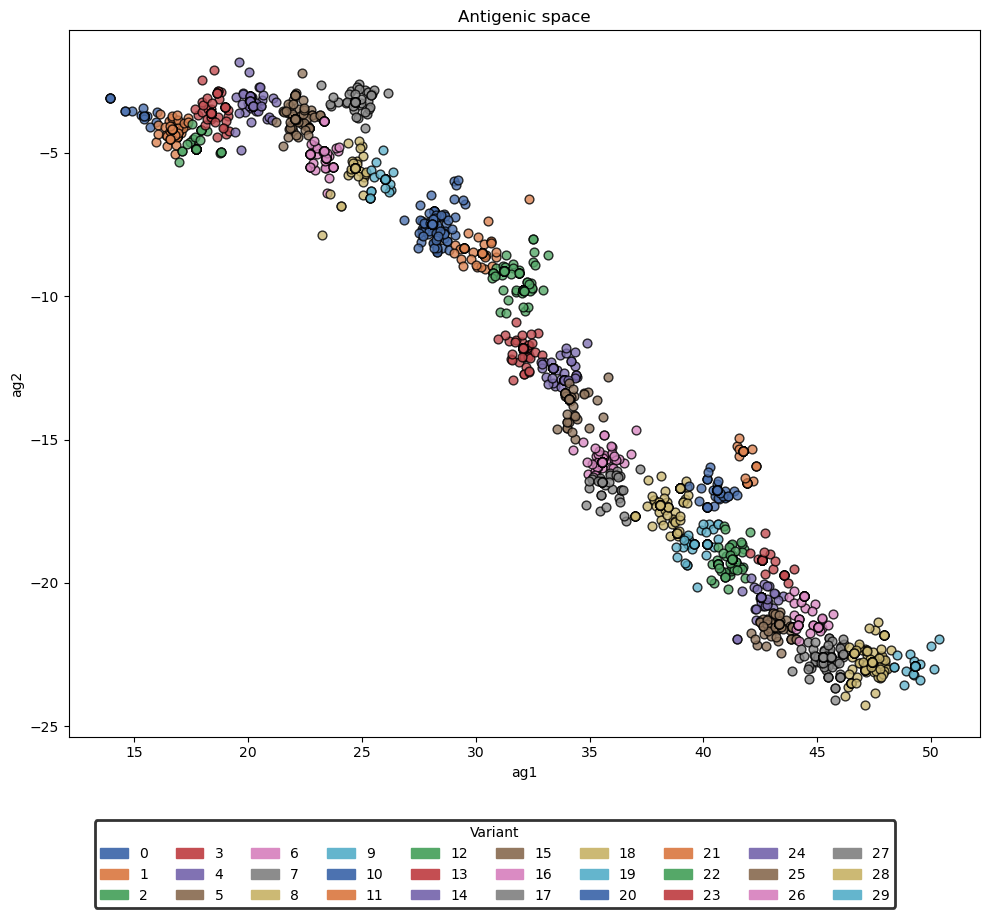

In [10]:
plot_antigenic_space_by_clade(
    tips_df, 
    color_map=color_map, 
    variant_col='variant_ag',
    figsize=(10, 8)
)

In [11]:
window_growth_rates_scores_path = f"../results/{build}/window_growth_rates.tsv"
variant_growth_rates_scores_path = f"../results/{build}/variant_growth_rates.tsv"
convergence_diagnostics_path = f"../results/{build}/vi_convergence_diagnostics.tsv"

# Load growth rate scores
window_growth_rate_errors_df = pd.read_csv(window_growth_rates_scores_path, sep="\t")
variant_growth_rate_errors_df = pd.read_csv(variant_growth_rates_scores_path, sep="\t")
convergence_diagnostics_df = pd.read_csv(convergence_diagnostics_path, sep="\t")

In [12]:
# Take a look at window growth rates
window_growth_rate_errors_df.head()

,pivot_date,model,location,correlation,mae,mse,rmse,r2,n_seqs,n_cases,seq_entropy,case_entropy,seq_entropy_norm,case_entropy_norm
0,2027-04-01,FGA,north,0.988793,0.002256,0.000007,0.002699,0.944428,682,5030,3.990554,3.975398,0.744847,0.697384
1,2027-10-01,FGA,north,0.998057,0.002016,0.000006,0.002348,0.991032,1779,12367,4.886218,4.879015,0.870253,0.855901
2,2028-04-01,FGA,north,0.970129,0.004712,0.000097,0.009836,0.929084,6065,43080,4.784663,4.752878,0.839350,0.833774
3,2028-10-01,FGA,north,0.997643,0.002633,0.000010,0.003122,0.993666,5135,36843,4.269809,4.249948,0.802305,0.745547
4,2030-04-01,FGA,north,0.982691,0.006277,0.000049,0.007015,0.531979,822,5792,3.504432,3.587309,0.694718,0.626285


## Variant-specific growth rate errors

In [13]:
print(f"Number of variant growth rate error entries: {len(variant_growth_rate_errors_df)}")
variant_growth_rate_errors_df.head()

Number of variant growth rate error entries: 500


,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged
0,0,2027-04-01,FGA,north,0.002208,0.000007,0.055011,0.040140,0.992298,0.947286,11,451.0,450.782225,0.805181,0.813323,0.913043,0.925431,True
1,1,2027-04-01,FGA,north,0.002388,0.000007,0.056469,0.042290,0.989729,0.802467,4,94.0,93.680988,0.268530,0.278828,0.339130,0.328898,True
2,0,2027-10-01,FGA,north,0.002518,0.000008,0.063123,0.039888,0.999395,0.988998,22,909.0,908.928104,0.628909,0.632575,0.913043,0.924235,True
3,1,2027-10-01,FGA,north,0.001514,0.000003,0.032377,0.046769,0.998684,0.993856,22,675.0,674.791827,0.544097,0.525291,0.941176,0.816234,True
4,0,2028-04-01,FGA,north,0.002134,0.000008,0.052889,0.040357,0.968594,0.899276,9,294.0,294.009470,0.393307,0.417283,0.512821,0.575952,True


In [14]:
# Only keep converged entries
variant_growth_rate_errors_df = variant_growth_rate_errors_df[variant_growth_rate_errors_df['converged'] == True]
print(f"Number of converged variant growth rate error entries: {len(variant_growth_rate_errors_df)}")

Number of converged variant growth rate error entries: 443


### MAE

In [15]:
variant_growth_rate_errors_df.head()

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged
0,0,2027-04-01,FGA,north,0.002208,0.000007,0.055011,0.040140,0.992298,0.947286,11,451.0,450.782225,0.805181,0.813323,0.913043,0.925431,True
1,1,2027-04-01,FGA,north,0.002388,0.000007,0.056469,0.042290,0.989729,0.802467,4,94.0,93.680988,0.268530,0.278828,0.339130,0.328898,True
2,0,2027-10-01,FGA,north,0.002518,0.000008,0.063123,0.039888,0.999395,0.988998,22,909.0,908.928104,0.628909,0.632575,0.913043,0.924235,True
3,1,2027-10-01,FGA,north,0.001514,0.000003,0.032377,0.046769,0.998684,0.993856,22,675.0,674.791827,0.544097,0.525291,0.941176,0.816234,True
4,0,2028-04-01,FGA,north,0.002134,0.000008,0.052889,0.040357,0.968594,0.899276,9,294.0,294.009470,0.393307,0.417283,0.512821,0.575952,True


In [16]:
# Calculate log(MAE) and add as new column
variant_growth_rate_errors_df['log_mae'] = np.log(variant_growth_rate_errors_df['mae'] + 1e-6)
variant_growth_rate_errors_df['log_mse'] = np.log(variant_growth_rate_errors_df['mse'] + 1e-6)

## Boxplot of log(MAE) of growth rate errors

In [17]:
save_path = '../../antigen-tex/figures/figureS3_growth_rates_log_error_boxplot'

Figure saved to ../../antigen-tex/figures/figureS3_growth_rates_log_error_boxplot.pdf and ../../antigen-tex/figures/figureS3_growth_rates_log_error_boxplot.png


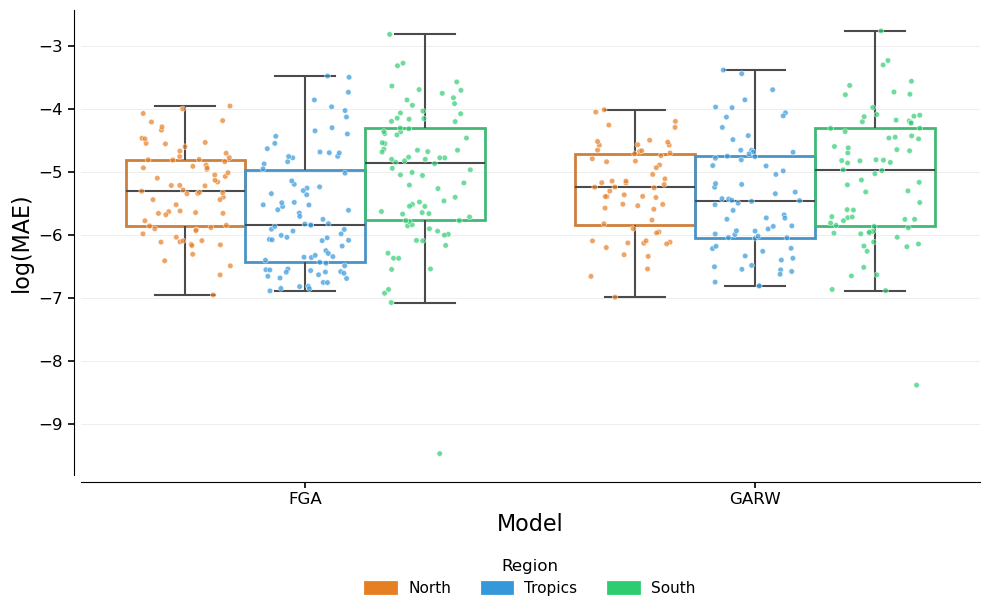

In [18]:
# Enhanced boxplot of log(MAE) by model and location with publication styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with refined styling
boxplot = sns.boxplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    showfliers=False,
    ax=ax,
    linewidth=1.5,
    fliersize=0
)

# Convert boxplots to outlined style for cleaner look
for patch in boxplot.patches:
    # Get the current face color for edge color
    edge_color = patch.get_facecolor()
    # Make boxes transparent with colored edges
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(2)

# Style the boxplot lines (whiskers, medians, etc.)
plt.setp(boxplot.lines, linewidth=1.5)

# Add refined stripplot overlay
sns.stripplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    dodge=True,
    jitter=0.3,  # Reduced jitter for cleaner look
    size=4,      # Slightly smaller points
    alpha=0.7,   # Slightly more transparent
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# Publication-style labels and formatting
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('log(MAE)', fontsize=16)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=4)
ax.tick_params(axis='both', which='minor', width=1, length=2)

# Create custom legend
legend_elements = []
for location in ['north', 'tropics', 'south']:
    from matplotlib.patches import Patch
    patch = Patch(facecolor=deme_palette[location], 
                 edgecolor=deme_palette[location],
                 linewidth=2,
                 label=location.capitalize())
    legend_elements.append(patch)

# Position legend horizontally below the plot
legend = ax.legend(handles=legend_elements, 
                  title='Region', 
                  title_fontsize=12,
                  fontsize=11,
                  ncol=3,  # Horizontal orientation
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # Position below plot
                  frameon=False
                  )

# Enhanced despine and grid
sns.despine(ax=ax, offset=5, trim=False)
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Improved layout with better margins to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Add space for horizontal legend
# Save figure and show
plt.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}.pdf and {save_path}.png")
plt.show()

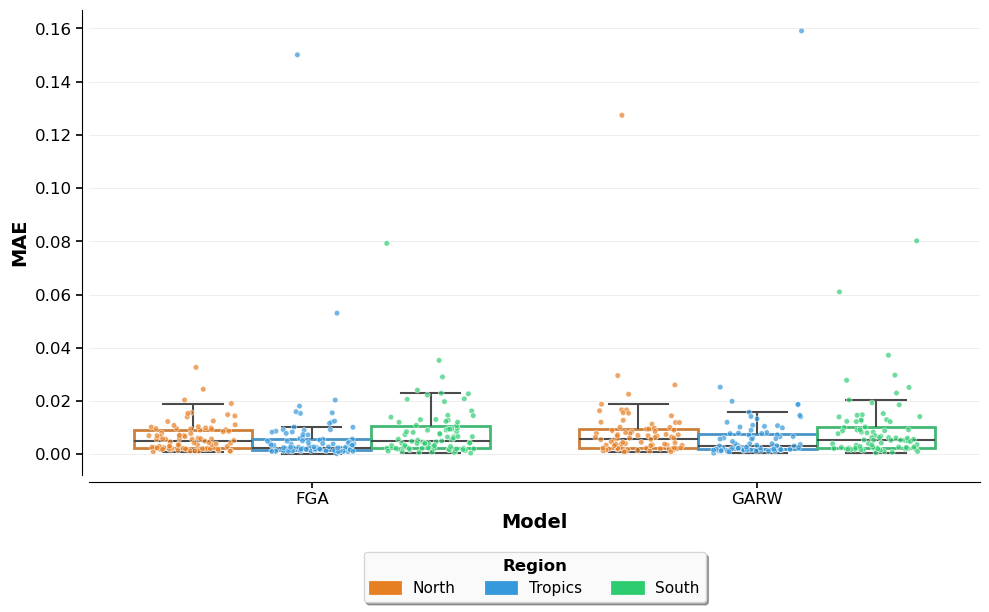

In [71]:
# Enhanced boxplot of log(MAE) by model and location with publication styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with refined styling
boxplot = sns.boxplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    showfliers=False,
    ax=ax,
    linewidth=1.5,
    fliersize=0
)

# Convert boxplots to outlined style for cleaner look
for patch in boxplot.patches:
    # Get the current face color for edge color
    edge_color = patch.get_facecolor()
    # Make boxes transparent with colored edges
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(2)

# Style the boxplot lines (whiskers, medians, etc.)
plt.setp(boxplot.lines, linewidth=1.5)

# Add refined stripplot overlay
sns.stripplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    dodge=True,
    jitter=0.3,  # Reduced jitter for cleaner look
    size=4,      # Slightly smaller points
    alpha=0.7,   # Slightly more transparent
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# Enhanced threshold line styling
# ax.axhline(y=-4, color='#d32f2f', linestyle='--', linewidth=2, alpha=0.8, zorder=10)
# ax.text(-0.51, -3.85, 'Threshold', fontsize=10, color='#d32f2f', 
#         style='italic', ha='left', va='bottom')

# Publication-style labels and formatting
ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE', fontsize=14, fontweight='bold')

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=4)
ax.tick_params(axis='both', which='minor', width=1, length=2)

# Create custom legend
legend_elements = []
for location in ['north', 'tropics', 'south']:
    from matplotlib.patches import Patch
    patch = Patch(facecolor=deme_palette[location], 
                 edgecolor=deme_palette[location],
                 linewidth=2,
                 label=location.capitalize())
    legend_elements.append(patch)

# Position legend horizontally below the plot
legend = ax.legend(handles=legend_elements, 
                  title='Region', 
                  title_fontsize=12,
                  fontsize=11,
                  ncol=3,  # Horizontal orientation
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # Position below plot
                  frameon=True,
                  framealpha=0.95,
                  edgecolor='lightgray',
                  fancybox=True,
                  shadow=True)
legend.get_title().set_fontweight('bold')

# Enhanced despine and grid
sns.despine(ax=ax, offset=5, trim=False)
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Improved layout with better margins to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Add space for horizontal legend
# Save figure and show
# plt.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
# print(f"Figure saved to {save_path}.pdf and {save_path}.png")
plt.show()

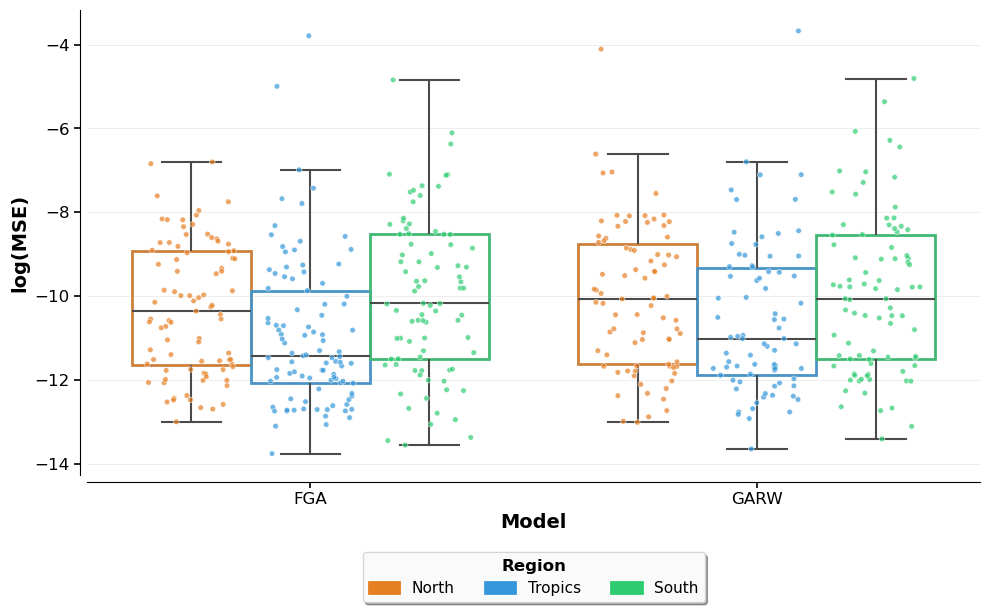

In [48]:
# Enhanced boxplot of log(MAE) by model and location with publication styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with refined styling
boxplot = sns.boxplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mse',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    showfliers=False,
    ax=ax,
    linewidth=1.5,
    fliersize=0
)

# Convert boxplots to outlined style for cleaner look
for patch in boxplot.patches:
    # Get the current face color for edge color
    edge_color = patch.get_facecolor()
    # Make boxes transparent with colored edges
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(2)

# Style the boxplot lines (whiskers, medians, etc.)
plt.setp(boxplot.lines, linewidth=1.5)

# Add refined stripplot overlay
sns.stripplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mse',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    dodge=True,
    jitter=0.3,  # Reduced jitter for cleaner look
    size=4,      # Slightly smaller points
    alpha=0.7,   # Slightly more transparent
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# # Enhanced threshold line styling
# ax.axhline(y=-4, color='#d32f2f', linestyle='--', linewidth=2, alpha=0.8, zorder=10)
# ax.text(-0.51, -3.85, 'Threshold', fontsize=10, color='#d32f2f', 
#         style='italic', ha='left', va='bottom')

# Publication-style labels and formatting
ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('log(MSE)', fontsize=14, fontweight='bold')
# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=4)
ax.tick_params(axis='both', which='minor', width=1, length=2)

# Create custom legend
legend_elements = []
for location in ['north', 'tropics', 'south']:
    from matplotlib.patches import Patch
    patch = Patch(facecolor=deme_palette[location], 
                 edgecolor=deme_palette[location],
                 linewidth=2,
                 label=location.capitalize())
    legend_elements.append(patch)

# Position legend horizontally below the plot
legend = ax.legend(handles=legend_elements, 
                  title='Region', 
                  title_fontsize=12,
                  fontsize=11,
                  ncol=3,  # Horizontal orientation
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # Position below plot
                  frameon=True,
                  framealpha=0.95,
                  edgecolor='lightgray',
                  fancybox=True,
                  shadow=True)
legend.get_title().set_fontweight('bold')

# Enhanced despine and grid
sns.despine(ax=ax, offset=5, trim=False)
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Improved layout with better margins to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Add space for horizontal legend
plt.show()

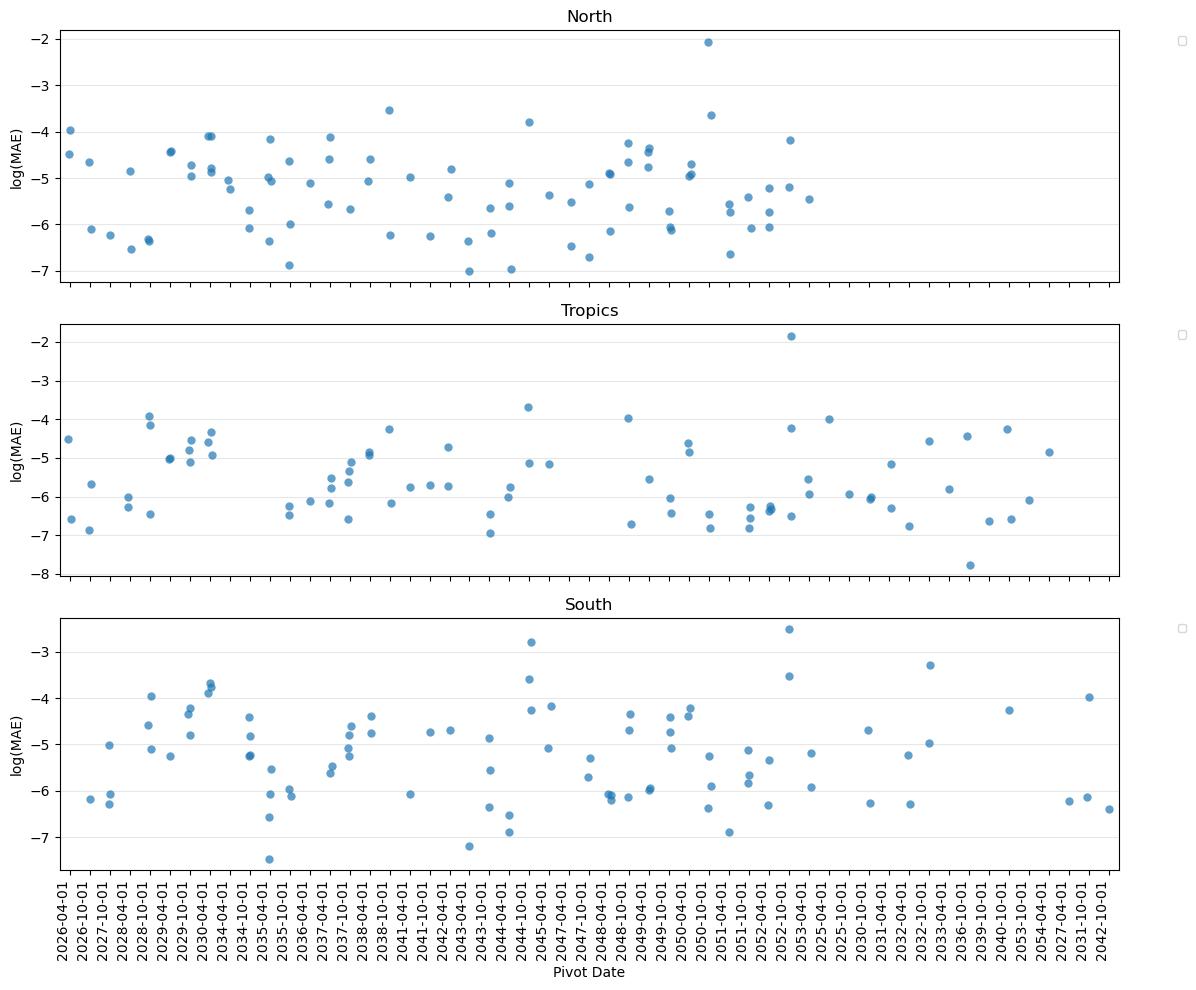

In [26]:
# Filter for GARW only -- look at log scale.
garw_df = variant_growth_rate_errors_df[variant_growth_rate_errors_df['model'] == 'GARW']

# Create 3x1 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

locations = ['north', 'tropics', 'south']

for ax, location in zip(axes, locations):
    # Filter for location
    loc_df = garw_df[garw_df['location'] == location]
    
    # Stripplot with jitter
    sns.stripplot(data=loc_df, x='pivot_date', y='log_mae', ax=ax, alpha=0.7, s=6, jitter=True)
    
    ax.set_ylabel('log(MAE)')
    ax.set_xlabel('')
    ax.set_title(f'{location.capitalize()}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Pivot Date')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# Grab all rows with log_MAE > error_threshold
error_threshold = -4
filtered_errors_df = variant_growth_rate_errors_df[variant_growth_rate_errors_df['log_mae'] > error_threshold]
filtered_errors_df.head()

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
0,1,2026-04-01,FGA,north,0.019055,0.000494,0.506876,0.037593,0.63304,0.110097,15,256.0,255.989772,0.457236,0.450948,1.000000,1.000000,True,-3.960384
16,5,2030-04-01,FGA,north,0.020394,0.000429,0.608946,0.033490,0.95871,-4.152562,9,256.0,255.876657,0.658432,0.674320,0.800000,0.693892,True,-3.892473
39,14,2038-10-01,FGA,north,0.032657,0.001066,2.098251,0.015564,NaN,NaN,1,11.0,10.870454,0.037671,0.029733,0.037671,0.029733,True,-3.421660
53,21,2044-10-01,FGA,north,0.024414,0.001113,0.421511,0.057920,0.71199,0.409483,25,3840.0,3840.018404,0.993716,0.976916,1.000000,1.000000,True,-3.712563
96,5,2028-10-01,FGA,south,0.020657,0.000429,0.678461,0.030447,1.00000,-89.343452,2,25.0,24.524416,0.892857,0.879037,0.928571,0.968720,True,-3.879660


In [67]:
low_bound = -6
upper_bound = -5
intermediate_errors_df = variant_growth_rate_errors_df[(variant_growth_rate_errors_df['log_mae'] >= low_bound) & (variant_growth_rate_errors_df['log_mae'] <= upper_bound)]
intermediate_errors_df.head()

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
18,7,2030-04-01,FGA,north,0.005713,0.000039,0.071781,0.079589,0.999599,0.978764,17,2076.0,2075.980178,0.405389,0.396726,0.750000,0.707812,True,-5.164845,-10.116116
19,6,2030-10-01,FGA,north,0.004648,0.000028,0.070491,0.065932,0.998841,0.982320,23,3789.0,3789.000201,0.661226,0.658464,0.961538,0.912633,True,-5.371186,-10.441856
20,7,2030-10-01,FGA,north,0.002496,0.000008,0.028793,0.086684,0.998585,0.996492,21,2173.0,2173.146651,0.490709,0.483435,0.928571,0.858633,True,-5.992713,-11.623519
21,8,2034-04-01,FGA,north,0.005611,0.000049,0.148642,0.037746,0.975253,0.573963,9,203.0,203.024615,0.722466,0.729910,0.833333,0.753586,True,-5.182910,-9.897900
22,9,2034-04-01,FGA,north,0.005665,0.000034,0.220072,0.025742,1.000000,-8.017679,2,23.0,22.968873,0.252660,0.238175,0.255319,0.245561,True,-5.173268,-10.260487


In [28]:
len(filtered_errors_df.query('location == "north"'))

9

## Northern deme zoom-in variants of interest

In [68]:
intermediate_errors_df.query('location == "north" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
294,8,2034-04-01,GARW,north,0.005367,0.000042,0.142187,0.037746,0.969978,0.637183,9,203.0,203.024615,0.722466,0.729910,0.833333,0.753586,True,-5.227297,-10.055070
295,9,2034-04-01,GARW,north,0.006512,0.000044,0.252977,0.025742,1.000000,-10.667949,2,23.0,22.968873,0.252660,0.238175,0.255319,0.245561,True,-5.033945,-10.009341
297,9,2034-10-01,GARW,north,0.003404,0.000015,0.179625,0.018951,0.997002,0.848057,5,57.0,56.721769,0.254040,0.215215,0.285714,0.222776,True,-5.682491,-11.026229
301,11,2035-04-01,GARW,north,0.006312,0.000041,0.138835,0.045467,0.999776,0.927815,13,300.0,299.998092,0.102149,0.097807,0.141892,0.120260,True,-5.065086,-10.071479
303,10,2035-10-01,GARW,north,0.002480,0.000010,0.039286,0.063119,0.997327,0.993014,26,3047.0,3046.951482,0.817535,0.821406,0.890909,0.896267,True,-5.999209,-11.405864
305,10,2036-04-01,GARW,north,0.006047,0.000051,0.094015,0.064317,0.432163,-0.083513,4,118.0,117.805700,0.843263,0.819653,0.890909,0.876763,True,-5.108073,-9.861342
306,12,2037-04-01,GARW,north,0.003887,0.000015,0.178168,0.021817,NaN,NaN,1,10.0,10.092317,0.087719,0.092898,0.087719,0.092898,True,-5.549819,-11.036070
309,14,2037-10-01,GARW,north,0.003448,0.000024,0.053325,0.064656,0.996016,0.978919,26,1945.0,1945.130686,0.883054,0.878890,1.000000,0.970279,True,-5.669742,-10.581431
310,14,2038-04-01,GARW,north,0.006366,0.000052,0.176922,0.035985,0.965565,0.699881,15,1086.0,1085.940244,0.966655,0.950699,1.000000,0.980211,True,-5.056556,-9.836119
317,19,2042-04-01,GARW,north,0.004525,0.000028,0.116825,0.038732,0.982928,0.613597,9,226.0,225.984532,0.808737,0.801341,0.911765,0.842743,True,-5.397938,-10.450138


In [50]:
filtered_errors_df.query('location == "north" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
273,1,2026-04-01,GARW,north,0.018803,0.000524,0.500185,0.037593,0.615188,0.057287,15,256.0,255.989772,0.457236,0.450948,1.000000,1.000000,True,-3.973671
312,14,2038-10-01,GARW,north,0.029552,0.000873,1.898741,0.015564,NaN,NaN,1,11.0,10.870454,0.037671,0.029733,0.037671,0.029733,True,-3.521569
326,21,2044-10-01,GARW,north,0.022570,0.000853,0.389674,0.057920,0.772501,0.547188,25,3840.0,3840.018404,0.993716,0.976916,1.000000,1.000000,True,-3.791095
347,25,2050-10-01,GARW,north,0.127358,0.016427,4.144116,0.030732,0.990781,-56.166357,11,167.0,166.785655,0.252075,0.298071,0.600000,0.479499,True,-2.060749
348,26,2050-10-01,GARW,north,0.026036,0.001340,0.583530,0.044619,0.995372,-0.920822,24,1147.0,1147.073769,0.867546,0.837394,1.000000,1.000000,True,-3.648218


In [53]:
filtered_errors_df.query('location == "north" and model == "FGA"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
0,1,2026-04-01,FGA,north,0.019055,0.000494,0.506876,0.037593,0.63304,0.110097,15,256.0,255.989772,0.457236,0.450948,1.000000,1.000000,True,-3.960384
16,5,2030-04-01,FGA,north,0.020394,0.000429,0.608946,0.033490,0.95871,-4.152562,9,256.0,255.876657,0.658432,0.674320,0.800000,0.693892,True,-3.892473
39,14,2038-10-01,FGA,north,0.032657,0.001066,2.098251,0.015564,NaN,NaN,1,11.0,10.870454,0.037671,0.029733,0.037671,0.029733,True,-3.421660
53,21,2044-10-01,FGA,north,0.024414,0.001113,0.421511,0.057920,0.71199,0.409483,25,3840.0,3840.018404,0.993716,0.976916,1.000000,1.000000,True,-3.712563


## Tropics deme zoom-in variants of interest

In [54]:
filtered_errors_df.query('location == "tropics" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
447,1,2025-04-01,GARW,tropics,0.018608,0.000817,6.462695,0.002879,0.074022,-600.817312,12,596.0,596.076667,0.957847,0.954049,1.000000,0.976873,True,-3.984121
461,5,2028-10-01,GARW,tropics,0.019899,0.000570,0.617905,0.032204,-0.373524,-20.417526,13,375.0,374.987786,0.567827,0.544117,0.777778,0.888856,True,-3.917027
516,21,2044-10-01,GARW,tropics,0.025215,0.001116,0.828089,0.030449,0.494105,-1.079441,41,3906.0,3906.000000,0.949337,0.934212,1.000000,1.000000,True,-3.680284
522,24,2048-10-01,GARW,tropics,0.018740,0.000455,1.388948,0.013492,-0.031770,-99.372643,8,134.0,133.826099,0.852722,0.833280,1.000000,0.898863,True,-3.977031
541,29,2052-10-01,GARW,tropics,0.159067,0.025405,13.348093,0.011917,-1.000000,-320408.660852,2,31.0,30.999997,0.652450,0.607401,0.684211,0.632720,True,-1.838425


In [55]:
filtered_errors_df.query('location == "tropics" and model == "FGA"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
174,1,2025-04-01,FGA,tropics,0.053003,0.006760,18.408666,0.002879,-0.090120,-4977.740569,12,596.0,596.076667,0.957847,0.954049,1.000000,0.976873,True,-2.937380
188,5,2028-10-01,FGA,tropics,0.020358,0.000593,0.632156,0.032204,-0.403044,-21.307419,13,375.0,374.987786,0.567827,0.544117,0.777778,0.888856,True,-3.894226
268,29,2052-10-01,FGA,tropics,0.150079,0.022609,12.593893,0.011917,-1.000000,-285148.180350,2,31.0,30.999997,0.652450,0.607401,0.684211,0.632720,True,-1.896586


## Southern deme zoom-in variants of interest

In [56]:
filtered_errors_df.query('location == "south" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
369,5,2028-10-01,GARW,south,0.019319,0.000378,0.634515,0.030447,1.000000,-78.615337,2,25.0,24.524416,0.892857,0.879037,0.928571,0.968720,True,-3.946623
374,4,2030-04-01,GARW,south,0.025115,0.000897,0.455303,0.055162,0.930992,0.241953,15,559.0,558.754445,0.106488,0.093424,0.159236,0.109712,True,-3.684239
375,5,2030-04-01,GARW,south,0.023000,0.000878,0.317735,0.072388,0.829327,0.351233,23,1807.0,1806.812967,0.473693,0.481661,1.000000,0.863330,True,-3.772205
376,6,2030-04-01,GARW,south,0.020411,0.000681,0.285730,0.071435,0.966180,0.683735,22,3427.0,3427.023876,0.624653,0.606911,0.898305,0.914100,True,-3.891635
379,7,2031-10-01,GARW,south,0.018558,0.000772,0.343899,0.053963,0.333414,-0.022819,4,56.0,55.602013,0.551196,0.520310,1.000000,0.965563,True,-3.986804
383,7,2032-10-01,GARW,south,0.037192,0.001861,0.731336,0.050855,0.996574,-2.038315,4,54.0,53.633334,0.111565,0.100535,0.138158,0.127949,True,-3.291631
415,21,2044-10-01,GARW,south,0.027787,0.001589,0.642014,0.043281,0.546545,-3.523616,50,4575.0,4574.996921,0.917608,0.912108,1.000000,1.000000,True,-3.583161
416,22,2044-10-01,GARW,south,0.061014,0.004686,1.065225,0.057278,0.729850,-7.024743,13,390.0,389.970119,0.187423,0.189490,0.366337,0.350578,True,-2.796630
443,28,2052-10-01,GARW,south,0.029728,0.002307,0.332123,0.089510,0.898718,-2.161490,49,3216.0,3216.044034,0.769057,0.769594,1.000000,0.947503,True,-3.515625
444,29,2052-10-01,GARW,south,0.080199,0.008152,1.548100,0.051805,0.958655,-8.363820,17,2026.0,2026.186724,0.472526,0.470833,0.775862,0.845797,True,-2.523226


In [57]:
filtered_errors_df.query('location == "south" and model == "FGA"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae
96,5,2028-10-01,FGA,south,0.020657,0.000429,0.678461,0.030447,1.000000,-89.343452,2,25.0,24.524416,0.892857,0.879037,0.928571,0.968720,True,-3.879660
101,4,2030-04-01,FGA,south,0.024088,0.000820,0.436679,0.055162,0.927992,0.306854,15,559.0,558.754445,0.106488,0.093424,0.159236,0.109712,True,-3.726002
102,5,2030-04-01,FGA,south,0.022220,0.000830,0.306959,0.072388,0.847043,0.387041,23,1807.0,1806.812967,0.473693,0.481661,1.000000,0.863330,True,-3.806706
103,6,2030-04-01,FGA,south,0.019785,0.000630,0.276967,0.071435,0.964715,0.707628,22,3427.0,3427.023876,0.624653,0.606911,0.898305,0.914100,True,-3.922779
106,7,2031-10-01,FGA,south,0.020802,0.000809,0.385483,0.053963,0.282987,-0.071676,4,56.0,55.602013,0.551196,0.520310,1.000000,0.965563,True,-3.872660
110,7,2032-10-01,FGA,south,0.035256,0.001706,0.693266,0.050855,0.996488,-1.784850,4,54.0,53.633334,0.111565,0.100535,0.138158,0.127949,True,-3.345088
141,20,2044-10-01,FGA,south,0.022926,0.000542,1.348425,0.017002,0.950855,-13.674533,3,44.0,43.669861,0.173389,0.156375,0.214286,0.180575,True,-3.775460
143,22,2044-10-01,FGA,south,0.022710,0.000621,0.396493,0.057278,0.862815,-0.063140,13,390.0,389.970119,0.187423,0.189490,0.366337,0.350578,True,-3.784885
170,28,2052-10-01,FGA,south,0.029045,0.002228,0.324494,0.089510,0.895725,-2.053452,49,3216.0,3216.044034,0.769057,0.769594,1.000000,0.947503,True,-3.538863
171,29,2052-10-01,FGA,south,0.079240,0.007880,1.529571,0.051805,0.957265,-8.051069,17,2026.0,2026.186724,0.472526,0.470833,0.775862,0.845797,True,-2.535268
